# Poder e tamanho de amostra

**Tema:** Estatística › Testes de Hipótese

Planejamento de experimento é engenharia, não estatística decorativa. Antes de
rodar qualquer teste você precisa responder: **quantas observações eu preciso
para detectar o efeito que me interessa?**

Quatro quantidades estão amarradas. Fixe três e a quarta fica determinada:

1. $\alpha$ — taxa de falso positivo que você tolera
2. **Poder** ($1-\beta$) — chance de detectar um efeito que existe
3. **Tamanho do efeito** — a magnitude que importa para o negócio
4. $n$ — o tamanho da amostra

> **Analogia:** é como fotografar à noite. $\alpha$ é o quanto de granulado
> você aceita, o efeito é o quão iluminado está o objeto, e $n$ é o tempo de
> exposição. Objeto escuro (efeito pequeno) exige exposição longa (n grande).
> Não existe almoço grátis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

rng = np.random.default_rng(2001)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. A curva de poder

Poder é uma **função** do tamanho do efeito, não um número. Vamos desenhá-la.

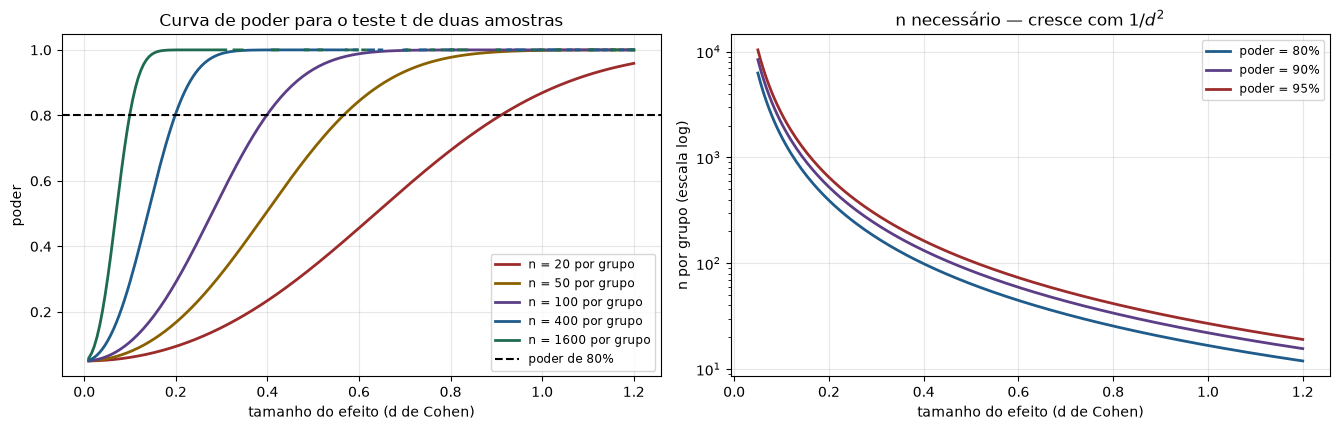

A relação n ∝ 1/d² em números:

  d de Cohen    interpretação    n por grupo (80%)
----------------------------------------------------
        0.80           grande                   26
        0.50            médio                   64
        0.20          pequeno                  393
        0.10    muito pequeno                1,571
        0.05        minúsculo                6,280
        0.02          trivial               39,245

A aproximação analítica n ≈ 15,7/d² reproduz a tabela:
   d=0.8 -> 15,7/d² =         25
   d=0.5 -> 15,7/d² =         63
   d=0.2 -> 15,7/d² =        392
   d=0.1 -> 15,7/d² =      1,570


In [2]:
analise = TTestIndPower()
efeitos = np.linspace(0.01, 1.2, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.4))

for n, cor in zip([20, 50, 100, 400, 1600], [VERMELHO, AMBAR, ROXO, AZUL, VERDE]):
    poder = analise.power(effect_size=efeitos, nobs1=n, alpha=0.05, ratio=1.0)
    ax1.plot(efeitos, poder, lw=2, color=cor, label=f"n = {n} por grupo")
ax1.axhline(0.80, ls="--", color="black", lw=1.5, label="poder de 80%")
ax1.set_xlabel("tamanho do efeito (d de Cohen)")
ax1.set_ylabel("poder")
ax1.set_title("Curva de poder para o teste t de duas amostras")
ax1.legend(fontsize=8.5)

# A vista dual: n necessário em função do efeito
ds = np.linspace(0.05, 1.2, 200)
for poder_alvo, cor in zip([0.80, 0.90, 0.95], [AZUL, ROXO, VERMELHO]):
    ns = [analise.solve_power(effect_size=d, power=poder_alvo, alpha=0.05, ratio=1.0)
          for d in ds]
    ax2.plot(ds, ns, lw=2, color=cor, label=f"poder = {poder_alvo:.0%}")
ax2.set_yscale("log")
ax2.set_xlabel("tamanho do efeito (d de Cohen)")
ax2.set_ylabel("n por grupo (escala log)")
ax2.set_title("n necessário — cresce com $1/d^2$")
ax2.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

print("A relação n ∝ 1/d² em números:\n")
print(f"{'d de Cohen':>12s} {'interpretação':>16s} {'n por grupo (80%)':>20s}")
print("-" * 52)
for d, rot in [(0.8, "grande"), (0.5, "médio"), (0.2, "pequeno"),
               (0.1, "muito pequeno"), (0.05, "minúsculo"), (0.02, "trivial")]:
    n = analise.solve_power(effect_size=d, power=0.80, alpha=0.05, ratio=1.0)
    print(f"{d:>12.2f} {rot:>16s} {n:>20,.0f}")
print("\nA aproximação analítica n ≈ 15,7/d² reproduz a tabela:")
for d in [0.8, 0.5, 0.2, 0.1]:
    print(f"   d={d:.1f} -> 15,7/d² = {15.7/d**2:>10,.0f}")

**Divida por quatro o efeito e o custo do experimento se multiplica por 16.**
É a economia do $\sqrt{n}$ mais uma vez, agora do ponto de vista do
planejamento.

## 2. Tamanho de amostra para um teste A/B de conversão

É o cálculo mais pedido no mercado. Vamos construir a tabela que todo time de
produto deveria ter na parede.

n POR GRUPO (α=5%, poder=80%, bilateral)

lift relativo        +2%      +5%     +10%    +20%   +50%
taxa base                                                
1%             3,923,546  636,915  163,004  42,606  7,673
2%             1,941,757  315,160   80,637  21,066  3,788
5%               752,684  122,107   31,217   8,143  1,457
10%              356,326   57,756   14,744   3,835    680
20%              158,147   25,580    6,507   1,680    292
40%               59,057    9,492    2,389     603     97


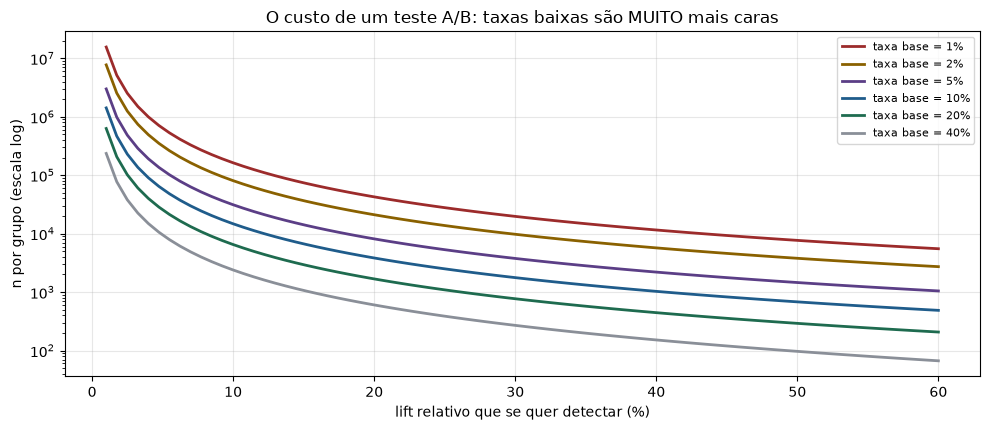

In [3]:
def n_para_ab(p_base, lift_relativo, poder=0.80, alpha=0.05, bilateral=True):
    """n POR GRUPO para detectar um lift relativo sobre a taxa base."""
    p_tratamento = p_base * (1 + lift_relativo)
    h = proportion_effectsize(p_tratamento, p_base)   # tamanho de efeito de Cohen (h)
    return NormalIndPower().solve_power(
        effect_size=h, power=poder, alpha=alpha, ratio=1.0,
        alternative="two-sided" if bilateral else "larger")


bases = [0.01, 0.02, 0.05, 0.10, 0.20, 0.40]
lifts = [0.02, 0.05, 0.10, 0.20, 0.50]

matriz = pd.DataFrame(
    [[n_para_ab(pb, lift) for lift in lifts] for pb in bases],
    index=pd.Index([f"{p:.0%}" for p in bases], name="taxa base"),
    columns=pd.Index([f"+{l:.0%}" for l in lifts], name="lift relativo"))

print("n POR GRUPO (α=5%, poder=80%, bilateral)\n")
print(matriz.map(lambda v: f"{v:,.0f}").to_string())

fig, ax = plt.subplots(figsize=(10, 4.4))
for pb, cor in zip(bases, [VERMELHO, AMBAR, ROXO, AZUL, VERDE, "#8A8F98"]):
    ns = [n_para_ab(pb, l) for l in np.linspace(0.01, 0.6, 80)]
    ax.plot(np.linspace(0.01, 0.6, 80) * 100, ns, lw=2, color=cor,
            label=f"taxa base = {pb:.0%}")
ax.set_yscale("log")
ax.set_xlabel("lift relativo que se quer detectar (%)")
ax.set_ylabel("n por grupo (escala log)")
ax.set_title("O custo de um teste A/B: taxas baixas são MUITO mais caras")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

> **Como usar essa tabela numa reunião:** o time quer testar uma mudança na
> tela de assinatura, cuja conversão base é 2%. Eles acham que vale a pena se
> melhorar 5%. A tabela diz: ~66 mil usuários **por grupo**. Se o produto tem
> 10 mil visitantes/dia nessa tela, o experimento leva **13 dias**. Essa é a
> conversa que evita testes rodados por 3 dias e conclusões falsas.

## 3. Traduzindo o efeito de negócio para o efeito estatístico

In [4]:
def planeja_experimento(nome, metrica, valor_base, dp_base, efeito_minimo_relativo,
                        trafego_diario, poder=0.80, alpha=0.05):
    """Traduz uma meta de negócio em dias de experimento."""
    delta = valor_base * efeito_minimo_relativo
    d = delta / dp_base
    n_grupo = TTestIndPower().solve_power(effect_size=d, power=poder,
                                          alpha=alpha, ratio=1.0)
    dias = 2 * n_grupo / trafego_diario
    print(f"\n### {nome}")
    print(f"   métrica ................. {metrica}")
    print(f"   valor base .............. {valor_base:,.2f}")
    print(f"   desvio-padrão ........... {dp_base:,.2f} "
          f"(CV = {dp_base/valor_base:.2f})")
    print(f"   efeito mínimo relevante . {efeito_minimo_relativo:.1%} "
          f"= {delta:,.2f}")
    print(f"   d de Cohen equivalente .. {d:.4f}")
    print(f"   n por grupo ............. {n_grupo:,.0f}")
    print(f"   tráfego diário total .... {trafego_diario:,}")
    print(f"   DURAÇÃO ESTIMADA ........ {dias:,.1f} dias", end="")
    print("   <-- inviável" if dias > 60 else "   <-- viável" if dias > 0 else "")


planeja_experimento("Checkout novo", "receita por sessão (R$)",
                    valor_base=42.0, dp_base=95.0,
                    efeito_minimo_relativo=0.03, trafego_diario=40_000)

planeja_experimento("Recomendação na home", "itens vistos por sessão",
                    valor_base=8.4, dp_base=6.1,
                    efeito_minimo_relativo=0.05, trafego_diario=40_000)

planeja_experimento("Mudança de cor do botão", "receita por sessão (R$)",
                    valor_base=42.0, dp_base=95.0,
                    efeito_minimo_relativo=0.005, trafego_diario=40_000)


### Checkout novo
   métrica ................. receita por sessão (R$)
   valor base .............. 42.00
   desvio-padrão ........... 95.00 (CV = 2.26)
   efeito mínimo relevante . 3.0% = 1.26
   d de Cohen equivalente .. 0.0133
   n por grupo ............. 89,238
   tráfego diário total .... 40,000
   DURAÇÃO ESTIMADA ........ 4.5 dias   <-- viável

### Recomendação na home
   métrica ................. itens vistos por sessão
   valor base .............. 8.40
   desvio-padrão ........... 6.10 (CV = 0.73)
   efeito mínimo relevante . 5.0% = 0.42
   d de Cohen equivalente .. 0.0689
   n por grupo ............. 3,312
   tráfego diário total .... 40,000
   DURAÇÃO ESTIMADA ........ 0.2 dias   <-- viável

### Mudança de cor do botão
   métrica ................. receita por sessão (R$)
   valor base .............. 42.00
   desvio-padrão ........... 95.00 (CV = 2.26)
   efeito mínimo relevante . 0.5% = 0.21
   d de Cohen equivalente .. 0.0022
   n por grupo ............. 3,212,516
   tráfe

O terceiro caso é o mais instrutivo: detectar 0,5% de lift em receita exigiria
anos de experimento. **A conclusão correta não é "rode mesmo assim" — é "esse
efeito não é detectável com o tráfego que temos".** As saídas possíveis são:
aumentar o efeito (mudança mais ousada), reduzir a variância (CUPED,
winsorização, métrica melhor) ou escolher outra métrica.

> **Repare no CV:** receita por sessão tem CV = 2,26 (desvio-padrão maior que a
> média — cauda pesada). "Itens vistos" tem CV = 0,73. **A métrica com menor CV
> é sempre mais barata de testar.** Escolher a métrica é uma decisão de
> engenharia de experimento, não só de negócio.

## 4. Reduzir a variância vale mais que aumentar o n

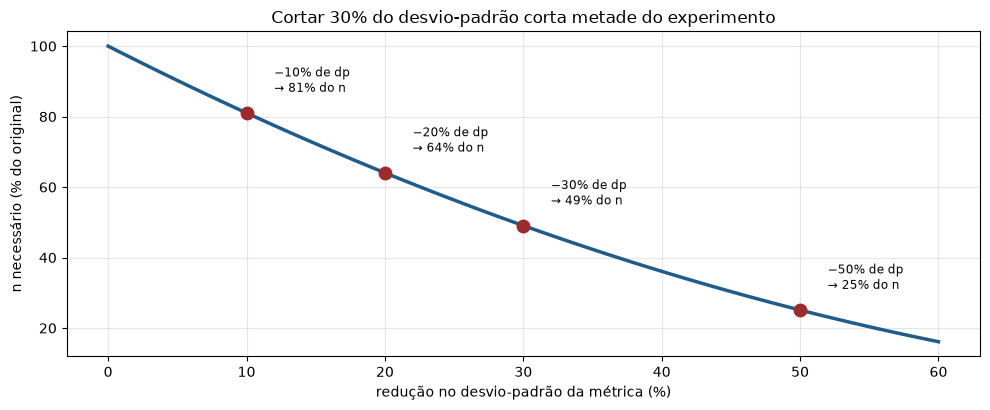

Como reduzir a variância de uma métrica, na prática:
  1. CUPED — usa o comportamento pré-experimento como covariável
  2. Winsorização — limita a cauda (com pré-registro do limite!)
  3. Estratificação / aleatorização em blocos
  4. Trocar a métrica: 'converteu?' (binária) costuma ter menos
     variância relativa que 'receita' (contínua de cauda pesada)
  5. Unidade de aleatorização mais granular, quando possível


In [5]:
p_reducao = np.linspace(0, 0.6, 60)     # redução percentual no desvio-padrão
d_base = 0.15
ns_por_reducao = [TTestIndPower().solve_power(
    effect_size=d_base / (1 - r), power=0.80, alpha=0.05, ratio=1.0)
    for r in p_reducao]
n_referencia = ns_por_reducao[0]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(p_reducao * 100, np.array(ns_por_reducao) / n_referencia * 100,
        lw=2.5, color=AZUL)
for r in [0.10, 0.20, 0.30, 0.50]:
    n_r = TTestIndPower().solve_power(effect_size=d_base / (1 - r), power=0.80,
                                      alpha=0.05, ratio=1.0)
    ax.plot(r * 100, n_r / n_referencia * 100, "o", ms=9, color=VERMELHO)
    ax.annotate(f"−{r:.0%} de dp\n→ {n_r/n_referencia:.0%} do n",
                xy=(r * 100, n_r / n_referencia * 100),
                xytext=(r * 100 + 2, n_r / n_referencia * 100 + 6), fontsize=8.5)
ax.set_xlabel("redução no desvio-padrão da métrica (%)")
ax.set_ylabel("n necessário (% do original)")
ax.set_title("Cortar 30% do desvio-padrão corta metade do experimento")
plt.tight_layout()
plt.show()

print("Como reduzir a variância de uma métrica, na prática:")
print("  1. CUPED — usa o comportamento pré-experimento como covariável")
print("  2. Winsorização — limita a cauda (com pré-registro do limite!)")
print("  3. Estratificação / aleatorização em blocos")
print("  4. Trocar a métrica: 'converteu?' (binária) costuma ter menos")
print("     variância relativa que 'receita' (contínua de cauda pesada)")
print("  5. Unidade de aleatorização mais granular, quando possível")

## 5. Por que análise de poder *post-hoc* é inútil

Calcular o poder **depois** do experimento, usando o efeito **observado**, não
acrescenta informação nenhuma: o resultado é uma função determinística do
p-valor obtido.

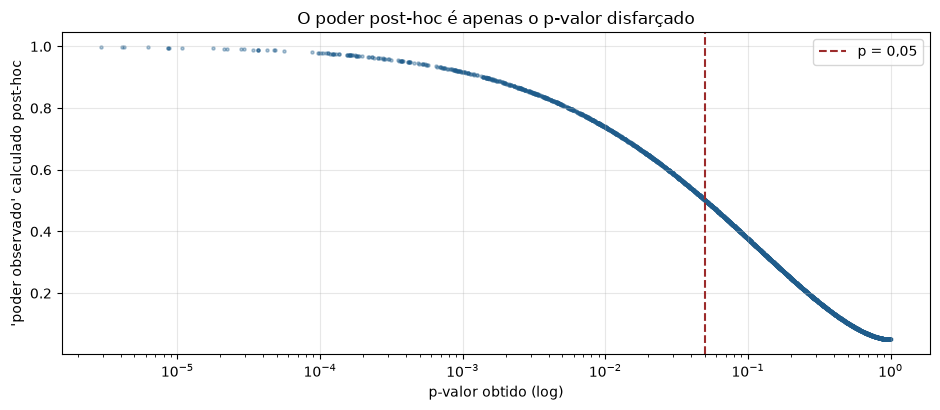

Correlação (Spearman) entre p-valor e poder observado: -1.0000

Poder observado médio quando p < 0,05 : 0.723
Poder observado médio quando p >= 0,05: 0.235

É uma relação DETERMINÍSTICA. Reportar 'o poder observado foi baixo'
depois de um resultado não-significativo é reformular o p-valor,
não trazer informação nova.


In [6]:
n = 60
poder_observado, p_valores = [], []
for _ in range(3_000):
    a = rng.normal(0, 1, n)
    b = rng.normal(0.3, 1, n)
    t = stats.ttest_ind(a, b, equal_var=False)
    d_obs = (b.mean() - a.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    poder_observado.append(
        TTestIndPower().power(effect_size=abs(d_obs), nobs1=n, alpha=0.05))
    p_valores.append(t.pvalue)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.scatter(p_valores, poder_observado, s=5, alpha=0.35, color=AZUL)
ax.axvline(0.05, ls="--", color=VERMELHO, lw=1.5, label="p = 0,05")
ax.set_xscale("log")
ax.set_xlabel("p-valor obtido (log)")
ax.set_ylabel("'poder observado' calculado post-hoc")
ax.set_title("O poder post-hoc é apenas o p-valor disfarçado")
ax.legend()
plt.tight_layout()
plt.show()

pv = np.array(p_valores)
po = np.array(poder_observado)
print(f"Correlação (Spearman) entre p-valor e poder observado: "
      f"{stats.spearmanr(pv, po).statistic:.4f}")
print(f"\nPoder observado médio quando p < 0,05 : {po[pv < 0.05].mean():.3f}")
print(f"Poder observado médio quando p >= 0,05: {po[pv >= 0.05].mean():.3f}")
print("\nÉ uma relação DETERMINÍSTICA. Reportar 'o poder observado foi baixo'")
print("depois de um resultado não-significativo é reformular o p-valor,")
print("não trazer informação nova.")

> **O que fazer no lugar:** reporte o **intervalo de confiança do efeito**. Ele
> responde à pergunta que interessa — "quais valores de efeito meus dados
> descartam?" — de forma direta e honesta.

## 6. Erro de tipo M: o estudo subdimensionado exagera o efeito

Um experimento com pouco poder tem um problema pior do que não detectar nada:
quando ele **detecta**, a estimativa é sistematicamente inflada. Só efeitos
anormalmente grandes conseguem cruzar o limiar com pouca amostra.

Efeito verdadeiro: d = 0.2

             poder  efeito médio (todos)  efeito médio (só significativos)  exagero (tipo M)  sinal errado (tipo S)
n por grupo                                                                                                        
15           0.079                 0.201                             0.800             4.001                  0.074
30           0.115                 0.201                             0.616             3.078                  0.029
60           0.187                 0.198                             0.461             2.305                  0.005
150          0.424                 0.205                             0.313             1.566                  0.000
400          0.804                 0.199                             0.224             1.119                  0.000
1000         0.994                 0.201                             0.202             1.008                  0.000


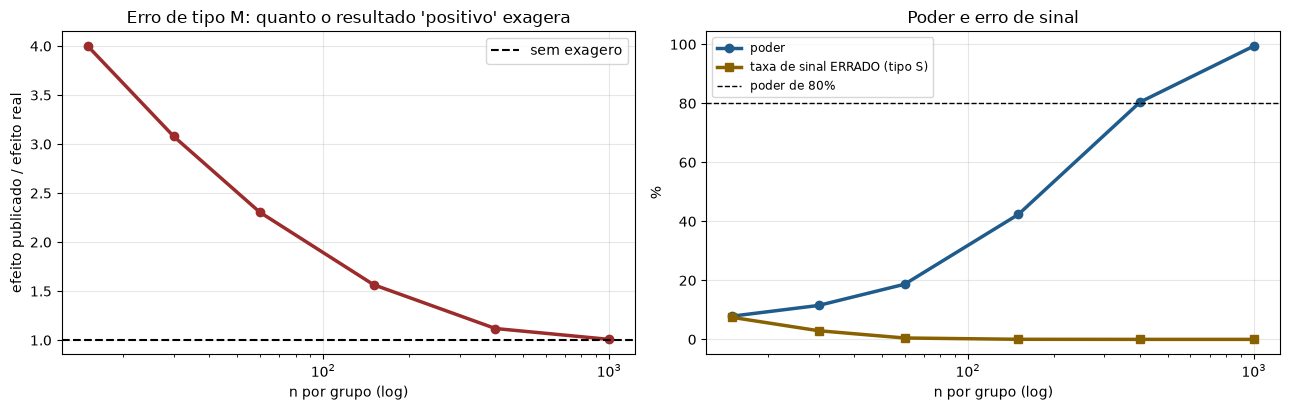

In [7]:
EFEITO_VERDADEIRO = 0.20      # d de Cohen real, pequeno
linhas = []
for n in [15, 30, 60, 150, 400, 1000]:
    a = rng.normal(0, 1, (8_000, n))
    b = rng.normal(EFEITO_VERDADEIRO, 1, (8_000, n))
    t = stats.ttest_ind(b, a, axis=1, equal_var=False)
    d_obs = (b.mean(axis=1) - a.mean(axis=1)) / np.sqrt(
        (a.var(axis=1, ddof=1) + b.var(axis=1, ddof=1)) / 2)
    signif = t.pvalue < 0.05
    linhas.append({
        "n por grupo": n,
        "poder": signif.mean(),
        "efeito médio (todos)": d_obs.mean(),
        "efeito médio (só significativos)": d_obs[signif].mean() if signif.any() else np.nan,
        "exagero (tipo M)": (d_obs[signif].mean() / EFEITO_VERDADEIRO
                             if signif.any() else np.nan),
        "sinal errado (tipo S)": (d_obs[signif] < 0).mean() if signif.any() else np.nan,
    })
tipo_m = pd.DataFrame(linhas).set_index("n por grupo")
print(f"Efeito verdadeiro: d = {EFEITO_VERDADEIRO}\n")
print(tipo_m.round(3).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
ax1.plot(tipo_m.index, tipo_m["exagero (tipo M)"], "o-", lw=2.5, color=VERMELHO)
ax1.axhline(1.0, ls="--", color="black", lw=1.5, label="sem exagero")
ax1.set_xscale("log")
ax1.set_xlabel("n por grupo (log)")
ax1.set_ylabel("efeito publicado / efeito real")
ax1.set_title("Erro de tipo M: quanto o resultado 'positivo' exagera")
ax1.legend()

ax2.plot(tipo_m.index, tipo_m["poder"] * 100, "o-", lw=2.5, color=AZUL,
         label="poder")
ax2.plot(tipo_m.index, tipo_m["sinal errado (tipo S)"] * 100, "s-", lw=2.5,
         color=AMBAR, label="taxa de sinal ERRADO (tipo S)")
ax2.axhline(80, ls="--", color="black", lw=1, label="poder de 80%")
ax2.set_xscale("log")
ax2.set_xlabel("n por grupo (log)")
ax2.set_ylabel("%")
ax2.set_title("Poder e erro de sinal")
ax2.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

Com $n = 15$, os resultados "significativos" exageram o efeito real em várias
vezes — e uma fração deles tem até o **sinal errado**.

> **Esta é uma das causas centrais da crise de replicação.** Estudos pequenos
> só publicam quando dão significativos, e quando dão significativos,
> exageram. A replicação com amostra maior então "falha" — quando na verdade é
> o estudo original que estava inflado. O mesmo mecanismo opera em experimentos
> de produto rodados com tráfego insuficiente.

## 7. Exercícios

1. Construa a tabela da seção 2 para um teste **unilateral**. Quanto de amostra
   se economiza? Em que situações o unilateral é legítimo, e em quais é
   p-hacking disfarçado?
2. Adicione a dimensão **razão de alocação** (90/10 em vez de 50/50). Quanto de
   poder se perde? Por que times às vezes aceitam essa perda?
3. Implemente o cálculo de $n$ para um teste **não-inferioridade** (provar que
   a nova versão não é pior que a antiga por mais que uma margem $\delta$).
4. Refaça a seção 6 com $\alpha = 0{,}005$ (o "p < 0,005" proposto por alguns
   metodologistas). O exagero de tipo M melhora ou piora? Por quê?

## Próximo passo

`04-comparacoes-multiplas.ipynb` — o que acontece quando você testa muitas
hipóteses, e como continuar honesto.